# Bibliotecas

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np
import re

In [2]:
# Graficas
import matplotlib.pyplot as plt
from matplotlib import cycler
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
# Escalamiento
from sklearn.preprocessing import StandardScaler

# Componentes principales
from sklearn.decomposition import PCA

# Modelo de clustering
from sklearn.cluster import KMeans

# Métricas para selección de clusters
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

# Pruebas estadísticas
from scipy.stats import kruskal

In [4]:
# !pip install nltk

from scipy import stats
from collections import Counter
import nltk # para trabajar con tokenizacion y stopwords (ejercicio 2)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Ejercicio 1

## Cargar datos

In [6]:
songs1 = pd.read_csv(r'https://raw.githubusercontent.com/Wsm-erick/Diplomado/refs/heads/main/Modulo-I/Datasets/features_songs.csv')

In [7]:
songs1.shape

(175, 40)

In [8]:
songs1.head()

,archivo,duration,rms,tempo,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_contrast,mfcc_1,...,chroma_9,chroma_10,chroma_11,chroma_12,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6
0,02 Maroon.mp3,218.305306,0.269286,[107.66601562],0.030423,2131.429071,3054.294473,4833.956751,21.985519,-165.31206,...,0.601635,0.531422,0.506995,0.518395,0.275898,0.210128,0.175254,0.011638,0.049738,-0.057944
1,03 Anti-Hero.mp3,200.724898,0.251603,[97.50884434],0.042470,2270.523020,2887.932364,4680.853820,20.961313,-116.05038,...,0.481668,0.461698,0.506635,0.596817,0.067301,-0.201125,-0.039244,0.056137,0.023695,-0.028362
2,04 Snow On The Beach.mp3,256.156735,0.191276,[109.95678191],0.026679,1691.923217,2516.562246,3338.831279,21.885129,-205.33786,...,0.507185,0.615904,0.499524,0.530878,0.140940,-0.188128,-0.098086,-0.042389,0.013691,-0.021691
3,"05 You_re On Your Own, Kid.mp3",194.246531,0.261242,[120.18531977],0.021683,1637.701889,2600.810313,3373.619237,21.883741,-183.35786,...,0.440590,0.486334,0.450555,0.462748,0.128289,0.005553,0.065578,-0.140425,0.006879,0.009277
4,06 Midnight Rain.mp3,174.837551,0.226225,[69.83741554],0.021928,1485.590595,2261.139587,3117.497364,21.791955,-223.94078,...,0.479455,0.510774,0.485107,0.532159,0.107616,0.223978,-0.027103,0.086051,0.020835,0.057351


## Descripción de las variables

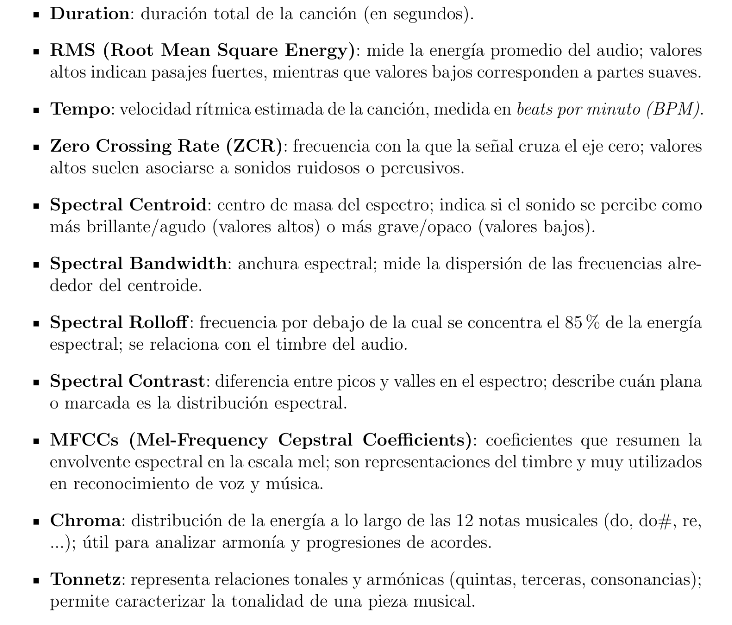

## Actividad

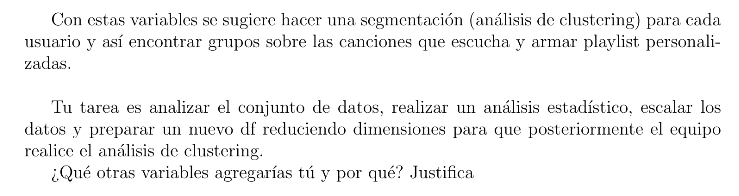

## Exploración

### Tipo de dato por variable

In [9]:
songs1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   archivo             175 non-null    object 
 1   duration            175 non-null    float64
 2   rms                 175 non-null    float64
 3   tempo               175 non-null    object 
 4   zcr                 175 non-null    float64
 5   spectral_centroid   175 non-null    float64
 6   spectral_bandwidth  175 non-null    float64
 7   spectral_rolloff    175 non-null    float64
 8   spectral_contrast   175 non-null    float64
 9   mfcc_1              175 non-null    float64
 10  mfcc_2              175 non-null    float64
 11  mfcc_3              175 non-null    float64
 12  mfcc_4              175 non-null    float64
 13  mfcc_5              175 non-null    float64
 14  mfcc_6              175 non-null    float64
 15  mfcc_7              175 non-null    float64
 16  mfcc_8  

### Valores ausentes

In [10]:
def is_na_df(df):
    #Establecemos el resumen de NAs por columna
    na_summary = (
        df.isna().sum()
        .reset_index()
        .rename(columns={"index": "columna", 0: "n_missing"})
    )

    #Tomamos totales y prporciones
    na_summary["total"] = len(df)
    na_summary["prop_missing"] = na_summary["n_missing"] / na_summary["total"]
    na_summary["prop_original"] = 1 - na_summary["prop_missing"]

    #Filtramos solo columnas con al menos 1 NA
    na_summary = na_summary[na_summary["n_missing"] > 0].reset_index(drop=True)

    #Agregamos fila resumen global
    total_missing = df.isna().sum().sum()
    total_elements = df.size
    prop_missing_global = total_missing / total_elements
    prop_original_global = 1 - prop_missing_global

    resumen = pd.DataFrame({
        "columna": ["TOTAL"],
        "n_missing": [total_missing],
        "total": [total_elements],
        "prop_missing": [prop_missing_global],
        "prop_original": [prop_original_global]
    })

    #Creamos la tabla
    na_summary = pd.concat([na_summary, resumen], ignore_index=True)

    return na_summary

In [11]:
is_na_df(songs1)

,columna,n_missing,total,prop_missing,prop_original
0,TOTAL,0,7000,0.0,1.0


No hay valores ausentes por lo que no hace falta aplicar un método de imputación.

### Distribución de variables numéricas

In [12]:
var_cat = songs1.select_dtypes(['object']).columns.tolist()
var_cat

['archivo', 'tempo']

In [13]:
songs1['tempo_num'] = songs1['tempo'].str[1:-1].astype(float)

In [14]:
def guess_lang_heuristic(text: str):

    spanish_words = {
        "el","la","los","las","un","una","unos","unas","de","del","al","y","o","u",
        "que","como","con","por","para","sin","sobre","entre","más","menos","mi","tu",
        "te","se","me","lo","le","su","si","ya","no","sí","a","en"
    }

    tokens = {t for t in re.findall(r"\b\w+\b", text)}
    hits = len(tokens & spanish_words)

    # si tiene acentos/símbolos muy comunes en español, suma
    accent_bonus = 1 if re.search(r"[áéíóúñü]", text.lower()) else 0
    score_es = hits + accent_bonus

    # título muy corto => baja confianza
    conf = min(1.0, 0.2*score_es + 0.2*(len(tokens) >= 3))
    if score_es >= 2:
        return "es", conf

    # si no hay indicios en español y tiene muchas palabras comunes en inglés
    english_words = {"the","and","you","your","i","me","my","on","in","with","for","of","to","from","at","it","is"}
    hits_en = len(tokens & english_words)
    if hits_en >= 2:
        return "en", max(conf, 0.6)

    # por defecto “en” si todo está en ASCII y sin acentos; si no, desconocido
    return ("en", 0.5) if text.isascii() else ("unk", 0.3)

In [15]:
def label_from_code(code):
    return {"es":"Español","en":"Inglés","unk":"Desconocido"}.get(code,"Desconocido")

In [16]:
songs1['archivo'] = songs1['archivo'].str.replace('.mp3' , '').str.lower()

In [17]:
songs1['archivo'].to_csv('canciones.csv')

In [18]:
songs1["lang_code"], songs1["lang_conf"] = zip(*songs1["archivo"].map(guess_lang_heuristic))
songs1["lang"] = songs1["lang_code"].map(label_from_code)

In [19]:
songs1.head(3)

,archivo,duration,rms,tempo,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_contrast,mfcc_1,...,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6,tempo_num,lang_code,lang_conf,lang
0,02 maroon,218.305306,0.269286,[107.66601562],0.030423,2131.429071,3054.294473,4833.956751,21.985519,-165.31206,...,0.275898,0.210128,0.175254,0.011638,0.049738,-0.057944,107.666016,en,0.5,Inglés
1,03 anti-hero,200.724898,0.251603,[97.50884434],0.042470,2270.523020,2887.932364,4680.853820,20.961313,-116.05038,...,0.067301,-0.201125,-0.039244,0.056137,0.023695,-0.028362,97.508844,en,0.5,Inglés
2,04 snow on the beach,256.156735,0.191276,[109.95678191],0.026679,1691.923217,2516.562246,3338.831279,21.885129,-205.33786,...,0.140940,-0.188128,-0.098086,-0.042389,0.013691,-0.021691,109.956782,en,0.6,Inglés


In [20]:
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas (cada una en figura independiente)
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2, subplot_titles=(f"{var} - Boxplot", f"{var} - Histograma"))

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#008080"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             #marker_color="#00a77d",
                             #marker_color='#722F37',
                             marker_color="rgba(114, 47, 55, 0.5)",  # burdeos con 50% transparencia
                             nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable numérica: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        n = len(self.cat_vars)
        cols = 2
        rows = (n + 1) // cols if n > 1 else 1

        fig = make_subplots(
            rows=rows, cols=cols,
            specs=[[{'type':'domain'}]*cols for _ in range(rows)],
            subplot_titles=self.cat_vars
        )

        for i, var in enumerate(self.cat_vars):
            row = i // cols + 1
            col = i % cols + 1

            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            wine_palette = [
                "#722F37", "#B85042", "#E6AF2E", "#F6D55C", "#F4A7B9",
                "#2F4F4F", "#8D6E63", "#A1887F", "#D7CCC8", "#795548"
            ]

            fig.add_trace(
                go.Pie(
                    labels=labels,
                    values=values,
                    name=var,
                    textinfo='percent+label',
                    marker=dict(colors=wine_palette)
                ),
                row=row, col=col
            )

            #fig.add_trace(
            #    go.Pie(labels=labels, values=values, name=var, textinfo='percent+label'),
            #    row=row, col=col
            #)

        fig.update_layout(title_text="Variables Categóricas", height=400*rows)
        fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self, color: str, values: bool = True):
        corr_matrix = self.df[self.num_vars].corr()

        if values:
            fig = go.Figure(data=go.Heatmap(
                z=corr_matrix.values,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                colorscale=color,
                text=corr_matrix.round(1).values,      # valores de correlación con 1 decimal
                texttemplate="%{text}",                # mostrar texto en cada celda
                textfont={"size":10, "color":"black"}  # estilo de fuente
                ))
        else:
            fig = go.Figure(data=go.Heatmap(
                z=corr_matrix.values,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                colorscale=color
                ))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

In [21]:
var_cat = songs1.select_dtypes('object').columns.tolist()
var_num = list(set(songs1.columns)-set(var_cat))
var_cat

['archivo', 'tempo', 'lang_code', 'lang']

In [22]:
analisis = analyze(songs1, var_num, ['lang'])

In [23]:
songs1.describe()

,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_contrast,mfcc_1,mfcc_2,mfcc_3,...,chroma_11,chroma_12,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6,tempo_num,lang_conf
count,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,...,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000
mean,242.625580,0.178263,0.058199,2648.488772,2988.567941,5473.065749,21.801889,-158.931074,140.614699,-26.212339,...,0.456177,0.466682,0.040485,0.032733,0.013377,0.013172,0.002823,-0.002182,111.935760,0.535429
std,67.956199,0.049730,0.018800,635.439223,500.307972,1397.766313,0.858255,38.227926,21.623594,21.760878,...,0.085315,0.070548,0.103817,0.102631,0.069900,0.077798,0.019156,0.021415,22.777153,0.116962
min,124.240000,0.055421,0.018877,1036.709252,1320.658488,1975.675843,19.465870,-276.422400,85.240814,-75.233640,...,0.237338,0.254564,-0.222699,-0.293091,-0.228473,-0.211357,-0.046127,-0.063731,69.837416,0.300000
25%,191.916952,0.138568,0.044932,2252.657618,2654.740590,4612.901963,21.283166,-181.099535,125.182952,-42.279401,...,0.405111,0.425203,-0.032431,-0.028935,-0.037906,-0.042667,-0.009250,-0.014530,97.508844,0.500000
50%,229.111293,0.178693,0.057285,2645.661730,2989.998973,5520.686528,21.773645,-154.530210,139.702700,-26.979185,...,0.461059,0.466638,0.036603,0.038114,0.008709,0.019528,0.004239,-0.002709,107.666016,0.500000
75%,280.912120,0.209344,0.071291,3040.246637,3308.289221,6251.972851,22.263098,-133.741050,155.288480,-15.626485,...,0.508748,0.517050,0.122870,0.099992,0.053448,0.068193,0.012924,0.011443,120.185320,0.600000
max,472.201020,0.307894,0.106914,4261.901169,4387.397055,9319.848099,24.342274,-84.056380,220.203380,36.474575,...,0.642065,0.682561,0.290125,0.262957,0.175254,0.220034,0.049738,0.063773,198.768029,1.000000


In [24]:
analisis.plot_num()

In [25]:
analisis.plot_cat()

In [26]:
songs1.query("lang == 'Desconocido'").shape

(13, 44)

Eliminación de canciones de otro idioma distinto al inglés y al español

In [27]:
songs1.drop(songs1.query("lang == 'Desconocido'").index, inplace=True)

In [28]:
songs1.shape

(162, 44)

In [29]:
colors = ['aggrnyl', 'agsunset', 'algae', 'amp', 'armyrose', 'balance',
             'blackbody', 'bluered', 'blues', 'blugrn', 'bluyl', 'brbg',
             'brwnyl', 'bugn', 'bupu', 'burg', 'burgyl', 'cividis', 'curl',
             'darkmint', 'deep', 'delta', 'dense', 'earth', 'edge', 'electric',
             'emrld', 'fall', 'geyser', 'gnbu', 'gray', 'greens', 'greys',
             'haline', 'hot', 'hsv', 'ice', 'icefire', 'inferno', 'jet',
             'magenta', 'magma', 'matter', 'mint', 'mrybm', 'mygbm', 'oranges',
             'orrd', 'oryel', 'oxy', 'peach', 'phase', 'picnic', 'pinkyl',
             'piyg', 'plasma', 'plotly3', 'portland', 'prgn', 'pubu', 'pubugn',
             'puor', 'purd', 'purp', 'purples', 'purpor', 'rainbow', 'rdbu',
             'rdgy', 'rdpu', 'rdylbu', 'rdylgn', 'redor', 'reds', 'solar',
             'spectral', 'speed', 'sunset', 'sunsetdark', 'teal', 'tealgrn',
             'tealrose', 'tempo', 'temps', 'thermal', 'tropic', 'turbid',
             'turbo', 'twilight', 'viridis', 'ylgn', 'ylgnbu', 'ylorbr',
             'ylorrd']

In [30]:
analisis.corr_matrix('cividis', False)

## Tratamiento de Datos

In [31]:
# Categorías para la variable tempo

bins_tempo = [0, 90, 120, 150, 1000]  # cortes
labels_tempo = ["Lento (≤90)", "Medio (90–120)", "Rápido (120–150)", "Muy rápido (>150)"]

songs1["tempo"] = pd.cut(songs1["tempo_num"], bins=bins_tempo, labels=labels_tempo, ordered=True)

In [32]:
# Categorías para variable Zero crossing rate

bins_zcr = [0, 0.1, 0.3, 1.0]
labels_zcr = ["Bajo (≤0.1)", "Medio (0.1–0.3)", "Alto (>0.3)"]

songs1["zcr"] = pd.cut(songs1["zcr"], bins=bins_zcr, labels=labels_zcr, ordered=True)

In [33]:
# Categorías para variable centroid

bins_centroid = [0, 2000, 4000, 10000]
labels_centroid = ["Oscuro (≤2kHz)", "Equilibrado (2–4kHz)", "Brillante (>4kHz)"]

songs1["centroid"] = pd.cut(songs1["spectral_centroid"], bins=bins_centroid, labels=labels_centroid, ordered=True)

In [34]:
songs1.head()

,archivo,duration,rms,tempo,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_contrast,mfcc_1,...,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6,tempo_num,lang_code,lang_conf,lang,centroid
0,02 maroon,218.305306,0.269286,Medio (90–120),Bajo (≤0.1),2131.429071,3054.294473,4833.956751,21.985519,-165.31206,...,0.210128,0.175254,0.011638,0.049738,-0.057944,107.666016,en,0.5,Inglés,Equilibrado (2–4kHz)
1,03 anti-hero,200.724898,0.251603,Medio (90–120),Bajo (≤0.1),2270.523020,2887.932364,4680.853820,20.961313,-116.05038,...,-0.201125,-0.039244,0.056137,0.023695,-0.028362,97.508844,en,0.5,Inglés,Equilibrado (2–4kHz)
2,04 snow on the beach,256.156735,0.191276,Medio (90–120),Bajo (≤0.1),1691.923217,2516.562246,3338.831279,21.885129,-205.33786,...,-0.188128,-0.098086,-0.042389,0.013691,-0.021691,109.956782,en,0.6,Inglés,Oscuro (≤2kHz)
3,"05 you_re on your own, kid",194.246531,0.261242,Rápido (120–150),Bajo (≤0.1),1637.701889,2600.810313,3373.619237,21.883741,-183.35786,...,0.005553,0.065578,-0.140425,0.006879,0.009277,120.185320,en,0.6,Inglés,Oscuro (≤2kHz)
4,06 midnight rain,174.837551,0.226225,Lento (≤90),Bajo (≤0.1),1485.590595,2261.139587,3117.497364,21.791955,-223.94078,...,0.223978,-0.027103,0.086051,0.020835,0.057351,69.837416,en,0.5,Inglés,Oscuro (≤2kHz)


In [35]:
import pandas as pd

# columnas categóricas a transformar
categorical_cols = ["tempo", "zcr", "centroid"]


# one hot encoding con 0/1 directamente
songs_encoded = pd.get_dummies(
    songs1,
    columns=["tempo", "zcr", "centroid"],
    prefix=["tempo", "zcr", "centroid"],
    dtype=int
)

# revisamos el resultado
songs_encoded.head()






,archivo,duration,rms,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_contrast,mfcc_1,mfcc_2,mfcc_3,...,tempo_Lento (≤90),tempo_Medio (90–120),tempo_Rápido (120–150),tempo_Muy rápido (>150),zcr_Bajo (≤0.1),zcr_Medio (0.1–0.3),zcr_Alto (>0.3),centroid_Oscuro (≤2kHz),centroid_Equilibrado (2–4kHz),centroid_Brillante (>4kHz)
0,02 maroon,218.305306,0.269286,2131.429071,3054.294473,4833.956751,21.985519,-165.31206,139.87862,7.629366,...,0,1,0,0,1,0,0,0,1,0
1,03 anti-hero,200.724898,0.251603,2270.523020,2887.932364,4680.853820,20.961313,-116.05038,154.35641,-23.276833,...,0,1,0,0,1,0,0,0,1,0
2,04 snow on the beach,256.156735,0.191276,1691.923217,2516.562246,3338.831279,21.885129,-205.33786,153.48877,3.835200,...,0,1,0,0,1,0,0,1,0,0
3,"05 you_re on your own, kid",194.246531,0.261242,1637.701889,2600.810313,3373.619237,21.883741,-183.35786,155.48424,8.347482,...,0,0,1,0,1,0,0,1,0,0
4,06 midnight rain,174.837551,0.226225,1485.590595,2261.139587,3117.497364,21.791955,-223.94078,145.48550,27.482918,...,1,0,0,0,1,0,0,1,0,0


### Escalado

In [36]:
# Remove categorical columns before scaling
# categorical_cols_to_drop = ['zcr', 'tempo', 'centroid']
X = songs_encoded.drop(columns=['archivo','lang_code','lang','lang_conf'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Componentes Principales

In [37]:
class rPCA:
    #Inicializamos
    def __init__(self, dataframe, cols, n_comp):
        self.dataframe = dataframe
        self.cols = cols
        self.n_comp = n_comp

        if self.cols == None:
            self.dataframe = dataframe
        else:
            self.dataframe = dataframe[cols]

    #Ajustamos el PCA
    def r_pca(self):
        pca = PCA(n_components = self.n_comp)
        pca.fit(self.dataframe)
        self.df_trans = pd.DataFrame(pca.transform(self.dataframe), columns=[f'p_{i}' for i in range(len(pca.explained_variance_ratio_))])
        return self.df_trans, pca.explained_variance_ratio_.cumsum()

    #Diagrama del codo
    def plot_elbow(self):
        pca_temp = PCA().fit(self.dataframe)
        var_exp = pca_temp.explained_variance_ratio_
        cum_var_exp = var_exp.cumsum()

        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(var_exp) + 1), cum_var_exp, marker='o', linestyle='--', color='maroon')
        plt.xlabel('Número de Componentes')
        plt.ylabel('Varianza Acumulada Explicada')
        plt.title('Diagrama de Codo')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [38]:
var_num = list(set(songs_encoded.columns)-set(['archivo','lang_code','lang']))

In [39]:
var_num = [x for x in var_num if x != 'lang_conf']

In [40]:
pca_01 = rPCA(pd.DataFrame(X_scaled, columns=var_num), var_num, 0.90)

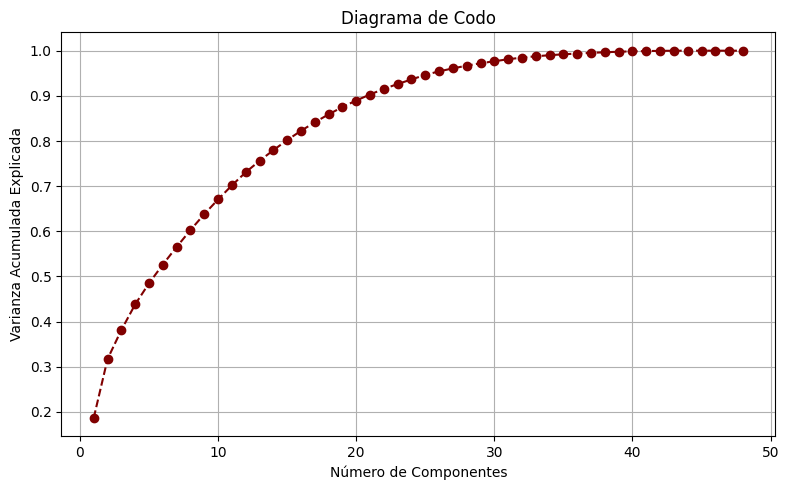

In [41]:
pca_01.plot_elbow()

In [42]:
print("Componentes:", pca_01.r_pca()[0].shape[1])

Componentes: 21


In [43]:
data = pca_01.r_pca()[0]
data.head()

,p_0,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,...,p_11,p_12,p_13,p_14,p_15,p_16,p_17,p_18,p_19,p_20
0,-4.272432,-3.045607,-0.306127,-0.052953,-2.747809,2.913387,0.250619,-0.232193,3.086848,2.114033,...,-0.338674,0.604587,1.157959,-0.429365,-0.855108,-0.493989,0.417656,-0.175246,-0.772895,-0.892168
1,-2.176789,-1.838124,0.636590,0.014626,-0.003197,-0.027929,-1.854189,1.188043,0.598204,2.600891,...,0.106022,0.534656,-1.452370,0.583695,-0.329456,0.409145,0.151455,0.182883,0.386453,-1.210673
2,0.863770,-4.440087,0.626783,-1.162318,-0.527755,0.526883,-3.700578,-0.635580,-0.672327,0.018515,...,0.786648,0.985588,-0.754633,0.010439,-0.467283,-0.192646,0.520910,0.303964,0.836719,-0.047208
3,-0.943756,-5.988590,-1.181105,0.992841,-1.229592,1.479780,-0.848687,-1.337133,0.567453,-1.430157,...,-1.878617,-1.910317,-1.134615,0.415941,-0.126613,-0.936664,-0.467314,2.362450,-0.606378,0.724857
4,0.953537,-5.872876,-0.028933,-3.228044,-0.063685,-0.058843,2.673665,-2.744610,0.041763,0.939831,...,-0.670586,-0.516063,0.324290,0.498730,0.139620,-0.338649,-1.305814,0.175754,1.140201,1.565008


## Conclusión

Al revisar la información que se entregará al equipo de clustering, encontramos veintiuno componentes principales que ayudan a describir mejor las canciones y facilitan elegir playlists más acertadas. El análisis muestra que la mayoría de los temas están en inglés y duran entre 3 y 4 minutos, lo cual coincide con lo típico de la música popular actual. También se identificó que varios corresponden a artistas muy conocidos del pop moderno, como Taylor Swift o Sabrina Carpenter, lo que conecta directamente los resultados con las tendencias musicales más escuchadas hoy en día.

Adicionalmente, se sugieren considerar siguientes variables:

*   Género musical
*   Número reproducciones mensuales

Con el objetivo de optimizar la selección de las mejores canciones para la recomendación de las canciones en la plataforma, ya que agregan una personalización basada en comportamiento colectivo e individual.


# Ejercicio 2

## Cargar datos

In [44]:
# !pip install openpyxl
songs2 = pd.read_excel(r'https://raw.githubusercontent.com/Wsm-erick/Diplomado/refs/heads/main/Modulo-I/Datasets/audio_features_lyrics.xlsx')

In [45]:
songs2.shape

(18172, 32)

In [46]:
songs2.head()

,album_name,ep,album_release,track_number,track_name,artist,featuring,bonus_track,promotional_release,single_release,...,time_signature,duration_ms,explicit,key_name,mode_name,key_mode,line,lyric,element,element_artist
0,Taylor Swift,0.0,2006-10-24,1.0,Tim McGraw,Taylor Swift,NaN,0.0,NaT,2006-06-19,...,4.0,232107.0,0.0,C,major,C major,1,He said the way my blue eyes shined,Verse 1,Taylor Swift
1,Taylor Swift,0.0,2006-10-24,1.0,Tim McGraw,Taylor Swift,NaN,0.0,NaT,2006-06-19,...,4.0,232107.0,0.0,C,major,C major,2,Put those Georgia stars to shame that night,Verse 1,Taylor Swift
2,Taylor Swift,0.0,2006-10-24,1.0,Tim McGraw,Taylor Swift,NaN,0.0,NaT,2006-06-19,...,4.0,232107.0,0.0,C,major,C major,3,"I said, ""That's a lie""",Verse 1,Taylor Swift
3,Taylor Swift,0.0,2006-10-24,1.0,Tim McGraw,Taylor Swift,NaN,0.0,NaT,2006-06-19,...,4.0,232107.0,0.0,C,major,C major,4,Just a boy in a Chevy truck,Verse 1,Taylor Swift
4,Taylor Swift,0.0,2006-10-24,1.0,Tim McGraw,Taylor Swift,NaN,0.0,NaT,2006-06-19,...,4.0,232107.0,0.0,C,major,C major,5,That had a tendency of gettin' stuck,Verse 1,Taylor Swift


## Descripción de las variables

![descimg1](songs2_var_description.png)
![descimg2](songs2_var_description2.png)
![descimg3](songs2_var_description3.png)
![descimg4](songs2_var_description4.png)

## Actividad

![actimg1](songs2_activity.png)
![actimg2](songs2_activity2.png)

In [47]:
songs2.tail(2)

,album_name,ep,album_release,track_number,track_name,artist,featuring,bonus_track,promotional_release,single_release,...,time_signature,duration_ms,explicit,key_name,mode_name,key_mode,line,lyric,element,element_artist
18170,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,NaN,NaT,2009-03-24,...,4.0,224187.0,0.0,G#,major,G# major,58,"You'll always, you'll always find your way",Outro,Taylor Swift
18171,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,NaN,NaT,2009-03-24,...,4.0,224187.0,0.0,G#,major,G# major,59,You'll always find your way (Back home) back home,Outro,Taylor Swift


## Exploración

In [48]:
songs2.iloc[:100].to_csv('muestra_dataset2.csv')

### Valores ausentes

In [49]:
is_na_df(songs2)

,columna,n_missing,total,prop_missing,prop_original
0,album_name,1779,18172,0.097898,0.902102
1,ep,1779,18172,0.097898,0.902102
2,album_release,1779,18172,0.097898,0.902102
3,track_number,1779,18172,0.097898,0.902102
4,featuring,15898,18172,0.874862,0.125138
5,bonus_track,1779,18172,0.097898,0.902102
6,promotional_release,15836,18172,0.871451,0.128549
7,single_release,14222,18172,0.782633,0.217367
8,danceability,579,18172,0.031862,0.968138
9,energy,579,18172,0.031862,0.968138


In [50]:
is_na_df(songs2).query('prop_missing > 0.15')

,columna,n_missing,total,prop_missing,prop_original
4,featuring,15898,18172,0.874862,0.125138
6,promotional_release,15836,18172,0.871451,0.128549
7,single_release,14222,18172,0.782633,0.217367


In [51]:
print('Moda: {0:.2%}'.format(stats.mode(is_na_df(songs2).prop_missing)[0]))
print('Media: {0:.2%}'.format(np.mean(is_na_df(songs2).prop_missing)))

Moda: 3.19%
Media: 14.12%


Tenemos 11% de valores ausentes en total del dataset, la moda de valores ausentes es de 3.19%. La media se eleva a 14.12% por variables como featuring, promotional_release y single_release que tienen más del 75% de valores ausentes, vamos a revisar si es necesario eliminar dichas variables.

In [52]:
dict_single_release = {x: i for i, x in enumerate(songs2['single_release'].unique().dropna())}
songs2['single_release_rec'] = songs2['single_release'].map(dict_single_release)
songs2.groupby('track_name')['single_release_rec'].mean().map(lambda x: 1 if x >= 0 else 'nan').value_counts()

single_release_rec
nan    287
1       76
Name: count, dtype: int64

In [53]:
dict_promotional_release = {x: i for i, x in enumerate(songs2['promotional_release'].unique().dropna())}
songs2['promotional_release_rec'] = songs2['promotional_release'].map(dict_promotional_release)
songs2.groupby('track_name')['promotional_release_rec'].mean().map(lambda x: 1 if x >= 0 else 'nan').value_counts()

promotional_release_rec
nan    318
1       45
Name: count, dtype: int64

In [54]:
dict_featuring = {x: i for i, x in enumerate(pd.Series(songs2['featuring'].unique()).dropna())}

print('Artistas que cantaron con Taylor en la pista:', len(dict_featuring))

songs2['featuring_rec'] = songs2['featuring'].map(dict_featuring)
songs2.groupby('track_name')['featuring_rec'].mean().map(lambda x: 1 if x >= 0 else 'nan').value_counts()

Artistas que cantaron con Taylor en la pista: 27


featuring_rec
nan    319
1       44
Name: count, dtype: int64

 Los conteos anteriores confirman que conviene eliminarlas debido a su alta concentración de valores ausentes (>15%).

In [55]:
songs2.drop(['featuring','promotional_release','single_release','featuring_rec','promotional_release_rec','single_release_rec'], axis=1, inplace=True)

In [56]:
print('Media: {0:.2%}'.format(np.mean(is_na_df(songs2).prop_missing)))

Media: 4.64%


Eliminando esas variables ya vemos que la media de valores ausentes se asimila a la moda.

### Tipo de dato por variable

In [57]:
songs2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18172 entries, 0 to 18171
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   album_name        16393 non-null  object        
 1   ep                16393 non-null  float64       
 2   album_release     16393 non-null  datetime64[ns]
 3   track_number      16393 non-null  float64       
 4   track_name        18172 non-null  object        
 5   artist            18172 non-null  object        
 6   bonus_track       16393 non-null  float64       
 7   track_release     18172 non-null  datetime64[ns]
 8   danceability      17593 non-null  float64       
 9   energy            17593 non-null  float64       
 10  key               17593 non-null  float64       
 11  loudness          17593 non-null  float64       
 12  mode              17593 non-null  float64       
 13  speechiness       17593 non-null  float64       
 14  acousticness      1759

In [58]:
# Clave o llave del track para agrupar líneas de letras (si hay varias filas por canción)
track_key = ["artist","album_name","track_number","track_name"]
track_key = [c for c in track_key if c in songs2.columns]

In [59]:
track_key

['artist', 'album_name', 'track_number', 'track_name']

In [60]:
songs2.loc[:, track_key]

,artist,album_name,track_number,track_name
0,Taylor Swift,Taylor Swift,1.0,Tim McGraw
1,Taylor Swift,Taylor Swift,1.0,Tim McGraw
2,Taylor Swift,Taylor Swift,1.0,Tim McGraw
3,Taylor Swift,Taylor Swift,1.0,Tim McGraw
4,Taylor Swift,Taylor Swift,1.0,Tim McGraw
...,...,...,...,...
18167,Hannah Montana,NaN,NaN,You'll Always Find Your Way Back Home
18168,Hannah Montana,NaN,NaN,You'll Always Find Your Way Back Home
18169,Hannah Montana,NaN,NaN,You'll Always Find Your Way Back Home
18170,Hannah Montana,NaN,NaN,You'll Always Find Your Way Back Home


In [61]:
songs2[songs2['track_name']=="You'll Always Find Your Way Back Home"].head()

,album_name,ep,album_release,track_number,track_name,artist,bonus_track,track_release,danceability,energy,...,time_signature,duration_ms,explicit,key_name,mode_name,key_mode,line,lyric,element,element_artist
18113,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,2009-03-24,0.577,0.906,...,4.0,224187.0,0.0,G#,major,G# major,1,Woo!,Intro,Taylor Swift
18114,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,2009-03-24,0.577,0.906,...,4.0,224187.0,0.0,G#,major,G# major,2,You wake up,Verse 1,Taylor Swift
18115,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,2009-03-24,0.577,0.906,...,4.0,224187.0,0.0,G#,major,G# major,3,It's raining and it's Monday,Verse 1,Taylor Swift
18116,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,2009-03-24,0.577,0.906,...,4.0,224187.0,0.0,G#,major,G# major,4,Looks like one of those rough days,Verse 1,Taylor Swift
18117,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,2009-03-24,0.577,0.906,...,4.0,224187.0,0.0,G#,major,G# major,5,Time's up,Verse 1,Taylor Swift


In [62]:
songs2[songs2['track_name']=="You'll Always Find Your Way Back Home"].shape

(59, 29)

In [63]:
songs2[songs2['track_name']=="You'll Always Find Your Way Back Home"]['line'].max()

59

El dataset viene a nivel lírica o línea de cada canción por lo que establecimos 'artist', 'album_name', 'track_number', 'track_name' como la llave para agrupar y obtener las características o métricas de cada canción para poder clusterizar.

In [64]:
songs2.query("artist == 'Taylor Swift'", inplace=True) # canciones de taylor swift como artista principal

In [65]:
songs2['artist'].unique() # validación que sólo traigamos a Taylor como artista

array(['Taylor Swift'], dtype=object)

In [66]:
songs2.shape # dimensión

(17204, 29)

## Tratamiento de Datos

### Funciones para obtener métricas de la letra y canciones

In [67]:
# instalar en primera ejecución
#nltk.download("stopwords"); nltk.download("punkt"); nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /home/erick/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/erick/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/erick/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [68]:
# campos principales (llave) por canción
track_key = [c for c in ["artist","album_name","track_number","track_name"] if c in songs2.columns]

# Download necessary NLTK data
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

# stopwords y vocales
stop_es = set(stopwords.words("spanish"))
stop_en = set(stopwords.words("english"))
stop_all = stop_es | stop_en

_vowels = re.compile(r"[aeiouáéíóúü]+", re.IGNORECASE)

def count_syllables(word: str) -> int:
    return max(1, len(_vowels.findall(word)))

def text_features(s: str) -> dict:
    if not isinstance(s, str) or not s.strip():
        return {"n_words":0,"n_unique":0,"lex_density":0.0,"avg_word_len":0.0,"avg_syllables":0.0,"stop_ratio":0.0}
    toks = [t.lower() for t in word_tokenize(s) if re.match(r"\w+", t)]
    if not toks:
        return {"n_words":0,"n_unique":0,"lex_density":0.0,"avg_word_len":0.0,"avg_syllables":0.0,"stop_ratio":0.0}

    n_words = len(toks)
    unique = len(set(toks))
    avg_len = float(np.mean([len(w) for w in toks]))
    avg_syl = float(np.mean([count_syllables(w) for w in toks]))
    n_stop = sum(w in stop_all for w in toks)
    lex_density = 1 - (n_stop / n_words)
    stop_ratio = n_stop / n_words

    return {
        "n_words": n_words,
        "n_unique": unique,
        "lex_density": lex_density,
        "avg_word_len": avg_len,
        "avg_syllables": avg_syl,
        "stop_ratio": stop_ratio,
    }

In [69]:
# Métricas de letra por canción

agg_text = (
    songs2.groupby(track_key)["lyric"]
      .apply(lambda s: "\n".join(s.dropna().astype(str)))  # concatenar letra completa
      .reset_index()
)

agg_text["n_lines"] = agg_text["lyric"].str.count(r"\n").fillna(0).astype(int) # líneas por canción
agg_text_feats = agg_text["lyric"].apply(text_features).apply(pd.Series) # features de la letra
agg_text["lyric"] = agg_text["lyric"].str.replace('\n', ' ') # sustituir saltos de línea por espacios
agg_text = pd.concat([agg_text[track_key + ['lyric','n_lines']], agg_text_feats], axis=1) # concatenar features de la letra por canción

print('Dimensión', agg_text.shape, end='\n\n')
display(agg_text.head(3))

Dimensión (326, 12)



,artist,album_name,track_number,track_name,lyric,n_lines,n_words,n_unique,lex_density,avg_word_len,avg_syllables,stop_ratio
0,Taylor Swift,1989,1.0,Welcome To New York,"Walking through a crowd, the village is aglow ...",43,348.0,91.0,0.557471,4.135057,1.399425,0.442529
1,Taylor Swift,1989,2.0,Blank Space,"Nice to meet you, where you been? I could show...",83,509.0,175.0,0.514735,3.555992,1.249509,0.485265
2,Taylor Swift,1989,3.0,Style,"Midnight You come and pick me up, no headlight...",47,383.0,120.0,0.522193,3.605744,1.245431,0.477807


In [70]:
# Proporción de elementos (coro, verso, intro…)
elem_props = (
    songs2.groupby(track_key + ["element"]).size().unstack(fill_value=0)
)
elem_props = elem_props.div(elem_props.sum(axis=1), axis=0)  # normalizar a proporciones
elem_props.columns = [f"elem_prop_{c}" for c in elem_props.columns]

print('Dimensión', elem_props.shape, end='\n\n')
display(elem_props.head(3))

Dimensión (326, 29)



elem_prop_Break  \
artist       album_name track_number track_name                             
Taylor Swift 1989       1.0          Welcome To New York              0.0   
                        2.0          Blank Space                      0.0   
                        3.0          Style                            0.0   

                                                          elem_prop_Breakdown  \
artist       album_name track_number track_name                                 
Taylor Swift 1989       1.0          Welcome To New York                  0.0   
                        2.0          Blank Space                          0.0   
                        3.0          Style                                0.0   

                                                          elem_prop_Bridge  \
artist       album_name track_number track_name                              
Taylor Swift 1989       1.0          Welcome To New York          0.090909   
                        2.0          Blank Space                  0.047619   
                        3.0          Style                        0.104167   

                                                          elem_prop_Bridge 1  \
artist       album_name track_number track_name                                
Taylor Swift 1989       1.0          Welcome To New York                 0.0   
                        2.0          Blank Space                         0.0   
                        3.0          Style                               0.0   

                                                          elem_prop_Bridge 2  \
artist       album_name track_number track_name                                
Taylor Swift 1989       1.0          Welcome To New York                 0.0   
                        2.0          Blank Space                         0.0   
                        3.0          Style                               0.0   

                                                          elem_prop_Buildup  \
artist       album_name track_number track_name                               
Taylor Swift 1989       1.0          Welcome To New York                0.0   
                        2.0          Blank Space                        0.0   
                        3.0          Style                              0.0   

                                                          elem_prop_Chorus  \
artist       album_name track_number track_name                              
Taylor Swift 1989       1.0          Welcome To New York          0.681818   
                        2.0          Blank Space                  0.571429   
                        3.0          Style                        0.479167   

                                                          elem_prop_Chorus - Variation  \
artist       album_name track_number track_name                                          
Taylor Swift 1989       1.0          Welcome To New York                           0.0   
                        2.0          Blank Space                                   0.0   
                        3.0          Style                                         0.0   

                                                          elem_prop_Chorus 1  \
artist       album_name track_number track_name                                
Taylor Swift 1989       1.0          Welcome To New York                 0.0   
                        2.0          Blank Space                         0.0   
                        3.0          Style                               0.0   

                                                          elem_prop_Chorus 2  \
artist       album_name track_number track_name                                
Taylor Swift 1989       1.0          Welcome To New York                 0.0   
                        2.0          Blank Space                         0.0   
                        3.0          Style                               0.0   

                                 

In [71]:
# Variables musicales (se repiten en todas las líneas → tomar promedio o el primero)

music_feats = (
    songs2.groupby(track_key)
      [["danceability","energy","valence","tempo","duration_ms","acousticness","instrumentalness","liveness"]]
      .mean()
)

print('Dimensión', music_feats.shape, end='\n\n')
display(music_feats.head(3))

Dimensión (326, 8)



danceability  \
artist       album_name track_number track_name                          
Taylor Swift 1989       1.0          Welcome To New York         0.789   
                        2.0          Blank Space                 0.760   
                        3.0          Style                       0.588   

                                                          energy  valence  \
artist       album_name track_number track_name                             
Taylor Swift 1989       1.0          Welcome To New York   0.634    0.658   
                        2.0          Blank Space           0.703    0.570   
                        3.0          Style                 0.791    0.487   

                                                            tempo  \
artist       album_name track_number track_name                     
Taylor Swift 1989       1.0          Welcome To New York  116.992   
                        2.0          Blank Space           95.997   
                        3.0          Style                 94.933   

                                                          duration_ms  \
artist       album_name track_number track_name                         
Taylor Swift 1989       1.0          Welcome To New York     212600.0   
                        2.0          Blank Space             231827.0   
                        3.0          Style                   231000.0   

                                                          acousticness  \
artist       album_name track_number track_name                          
Taylor Swift 1989       1.0          Welcome To New York       0.03480   
                        2.0          Blank Space               0.10300   
                        3.0          Style                     0.00245   

                                                          instrumentalness  \
artist       album_name track_number track_name                              
Taylor Swift 1989       1.0          Welcome To New York          0.000002   
                        2.0          Blank Space                  0.000000   
                        3.0          Style                        0.002580   

                                                          liveness  
artist       album_name track_number track_name                     
Taylor Swift 1989       1.0          Welcome To New York    0.3020  
                        2.0          Blank Space            0.0913  
                        3.0          Style                  0.1180

In [72]:
# Variables categóricas

cat_feats = (
    songs2.groupby(track_key)
      [["explicit","mode","time_signature"]]
      .mean()
)

print('Dimensión:', cat_feats.shape, end='\n\n')
display(cat_feats.head(3))

Dimensión: (326, 3)



explicit  mode  \
artist       album_name track_number track_name                            
Taylor Swift 1989       1.0          Welcome To New York       0.0   1.0   
                        2.0          Blank Space               0.0   1.0   
                        3.0          Style                     0.0   1.0   

                                                          time_signature  
artist       album_name track_number track_name                           
Taylor Swift 1989       1.0          Welcome To New York             4.0  
                        2.0          Blank Space                     4.0  
                        3.0          Style                           4.0

In [73]:
# Dataset final a nivel canción (se unen las variables musicales; los elementos por coro, verso, etc.; y, variables numéricas de texto)

df_song = music_feats.join(elem_props, how="left").reset_index()
df_song = df_song.merge(agg_text, on=track_key, how="left")
df_song = df_song.merge(cat_feats, on=track_key, how="left")

print("Dimensión final:", df_song.shape, end='\n\n')
df_song.head(3)

Dimensión final: (326, 52)



,artist,album_name,track_number,track_name,danceability,energy,valence,tempo,duration_ms,acousticness,...,n_lines,n_words,n_unique,lex_density,avg_word_len,avg_syllables,stop_ratio,explicit,mode,time_signature
0,Taylor Swift,1989,1.0,Welcome To New York,0.789,0.634,0.658,116.992,212600.0,0.03480,...,43,348.0,91.0,0.557471,4.135057,1.399425,0.442529,0.0,1.0,4.0
1,Taylor Swift,1989,2.0,Blank Space,0.760,0.703,0.570,95.997,231827.0,0.10300,...,83,509.0,175.0,0.514735,3.555992,1.249509,0.485265,0.0,1.0,4.0
2,Taylor Swift,1989,3.0,Style,0.588,0.791,0.487,94.933,231000.0,0.00245,...,47,383.0,120.0,0.522193,3.605744,1.245431,0.477807,0.0,1.0,4.0


In [74]:
metricas = {
    'd_letra': list(set(agg_text)-set(track_key+['lyric'])),
    'musicales': list(set(music_feats)-set(track_key+['lyric'])),
    'd_elementos': list(set(elem_props)-set(track_key+['lyric']))
}

In [75]:
print('métricas de letra\n\n' + ' | '.join(metricas['d_letra']))
print('\nmétricas de musicales\n\n' + ' | '.join(metricas['musicales']))
print("\nmétricas de elementos\n\n" + ' | '.join(metricas['d_elementos']))

métricas de letra

n_words | avg_word_len | n_lines | avg_syllables | lex_density | n_unique | stop_ratio

métricas de musicales

acousticness | tempo | duration_ms | instrumentalness | danceability | energy | liveness | valence

métricas de elementos

elem_prop_Breakdown | elem_prop_Verse 1 | elem_prop_Bridge 1 | elem_prop_Pre-Chorus | elem_prop_Pre-Chorus 3 | elem_prop_Bridge 2 | elem_prop_Chorus 1 | elem_prop_Break | elem_prop_Buildup | elem_prop_Outro | elem_prop_Refrain | elem_prop_Post-Chorus | elem_prop_Bridge | elem_prop_Verse 4 | elem_prop_Chorus | elem_prop_Verse 5 | elem_prop_Intro | elem_prop_Chorus 3 | elem_prop_Verse 2 | elem_prop_Chorus 2 | elem_prop_Verse | elem_prop_Interlude | elem_prop_Post-Chorus 2 | elem_prop_Spoken Outro | elem_prop_Verse 3 | elem_prop_Pre-Chorus 2 | elem_prop_Post-Chorus 1 | elem_prop_Chorus - Variation | elem_prop_Pre-Chorus 1


### Estadísticos

In [76]:
num_cols = [item for sublist in metricas.values() for item in sublist]
cat_cols = ["explicit","mode","time_signature"] # excluimos "album_name","track_number","track_name" porque traerá muchos valores distintos

In [77]:
analisis_songs2 = analyze(df_song, num_cols, cat_cols)

In [78]:
analisis_songs2.plot_num()

In [79]:
analisis_songs2.plot_cat()

* **explicit**: Logical. True si la letrá contiene letra explícita.
* **time_signature**: Compás general estimado
* **mode**: Modalidad de una pista. 0 es menor, 1 es mayor

La mayoría de las variables categóricas que decidimos dejar se concentra en más del 80% de la información en un valor por lo que no nos va a dar tanta información al interpretar. Por otra parte, las variables numéricas que corresponden a elementos de las canciones (coros, versos, puentes, etc.) tienen buena distribución algunas y otras se concentra en un intervalo de 0.02 y 0.05, prácticamente 0 variabilidad.

In [80]:
df_song.drop(["explicit","mode","time_signature"], axis=1, inplace=True)

In [81]:
print("Dimensión final:", df_song.shape, end='\n\n')
df_song.head(3)

Dimensión final: (326, 49)



,artist,album_name,track_number,track_name,danceability,energy,valence,tempo,duration_ms,acousticness,...,elem_prop_Verse 4,elem_prop_Verse 5,lyric,n_lines,n_words,n_unique,lex_density,avg_word_len,avg_syllables,stop_ratio
0,Taylor Swift,1989,1.0,Welcome To New York,0.789,0.634,0.658,116.992,212600.0,0.03480,...,0.000000,0.0,"Walking through a crowd, the village is aglow ...",43,348.0,91.0,0.557471,4.135057,1.399425,0.442529
1,Taylor Swift,1989,2.0,Blank Space,0.760,0.703,0.570,95.997,231827.0,0.10300,...,0.095238,0.0,"Nice to meet you, where you been? I could show...",83,509.0,175.0,0.514735,3.555992,1.249509,0.485265
2,Taylor Swift,1989,3.0,Style,0.588,0.791,0.487,94.933,231000.0,0.00245,...,0.000000,0.0,"Midnight You come and pick me up, no headlight...",47,383.0,120.0,0.522193,3.605744,1.245431,0.477807


In [82]:
is_na_df(df_song)

,columna,n_missing,total,prop_missing,prop_original
0,danceability,9,326,0.027607,0.972393
1,energy,9,326,0.027607,0.972393
2,valence,9,326,0.027607,0.972393
3,tempo,9,326,0.027607,0.972393
4,duration_ms,9,326,0.027607,0.972393
5,acousticness,9,326,0.027607,0.972393
6,instrumentalness,9,326,0.027607,0.972393
7,liveness,9,326,0.027607,0.972393
8,TOTAL,72,15974,0.004507,0.995493


### Escalado e Imputación de valores ausentes

In [83]:
num_cols = list(set(num_cols)-set(['mode','explicit','time_signature']))

In [84]:
print('Variables numéricas continuas:', len(num_cols))

Variables numéricas continuas: 44


In [85]:
# Pipelines
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ColumnTransformer
pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_scaled = pre.fit_transform(df_song)
feature_names = pre.get_feature_names_out()
print(X.shape, len(feature_names))

(162, 48) 44


In [86]:
is_na_df(pd.DataFrame(X_scaled))

,columna,n_missing,total,prop_missing,prop_original
0,TOTAL,0,14344,0.0,1.0


Se imputa las variables numéricas con valores ausentes con la mediana de la muestra y posteriormente se escala (pipeline).

### Componentes Principales

In [87]:
pca_02 = rPCA(pd.DataFrame(X_scaled, columns=num_cols), num_cols, 0.90)

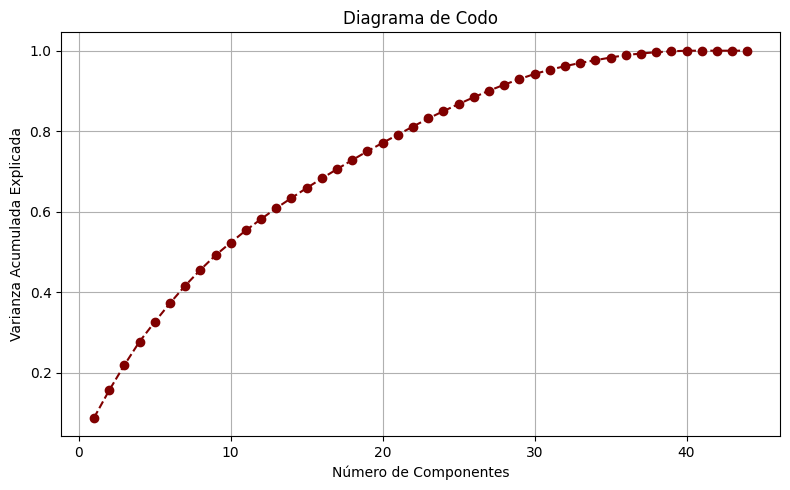

In [88]:
pca_02.plot_elbow()

In [89]:
print("Componentes:", pca_02.r_pca()[0].shape[1])

Componentes: 27


In [90]:
data_music = pca_02.r_pca()[0]
data_music.head()

,p_0,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,...,p_17,p_18,p_19,p_20,p_21,p_22,p_23,p_24,p_25,p_26
0,-1.451481,-0.622973,3.108158,-1.738774,0.762062,0.976005,0.343542,-0.539140,-0.574734,-0.100751,...,0.266773,0.188895,0.165732,-0.523331,-0.193427,0.331329,0.286880,-1.224959,-0.373499,1.134429
1,3.762034,-3.336996,-1.099643,-1.198087,2.557713,0.286523,1.795585,-2.060983,1.636565,2.840902,...,0.623629,0.098387,0.090792,-0.036570,-0.771081,1.824917,-0.011316,-0.869628,-1.237887,-1.742068
2,-0.624908,0.473218,1.584453,-0.073150,0.627905,-0.312096,1.489761,-0.927106,-0.210364,-0.030075,...,-0.366642,-0.694444,-0.598953,0.170234,0.250781,0.954548,0.845296,0.802224,-0.311958,-0.746278
3,3.392823,0.598721,0.707992,2.899723,0.200507,-1.028647,0.964340,-0.913741,-0.808029,-0.861617,...,0.001782,-0.088834,-0.320378,0.300650,0.553632,-0.195602,0.532048,0.362731,-0.029538,1.771398
4,3.838298,2.036571,0.960966,2.292115,0.671147,-0.160888,1.240010,1.431865,1.595797,-0.071535,...,-0.648760,0.572679,-0.349001,0.318898,-1.649879,-0.952483,-0.389717,0.870545,0.701508,0.489911


## Conclusión

Se proporcionó información con treinta y dos componentes a considerar para el respectivo análisis en el cual se realizó la limpieza de datos, imputación de valores faltantes y normalización de variables. Posteriormente, se aplicó un escalado y un PCA, reduciendo el dataset a veintisiete componentes que explican el 90% de la varianza. Esto permitió simplificar la información sin perder detalles importantes y dejar los datos listos para usarse en modelos de recomendación o agrupamiento. Con lo anterior podemos decir que se obtuvo una base sólida y ordenada para explorar patrones musicales y de consumo de manera más eficiente.

Para un análisis más complejo, resulta útil considerar las siguientes variables adicionales:
cantidad de vistas

*   Cantidad de vistas
*   Intervalos de tiempo más escuchados en plataformas como YouTube o Spotify
edad del público oyente.

Con estos datos sería posible identificar qué canciones generan mayor interés en la audiencia y, en particular, qué fragmentos captan más su atención. Además, al disponer de las letras, se pueden analizar los estilos rítmicos y las temáticas líricas que resultan más atractivos, ofreciendo una base sólida para orientar la composición de futuras canciones hacia patrones de preferencia del público.

En este sentido, puede definirse como variable objetivo la ‘popularidad de la canción', medida a través de la cantidad de visitas o reproducciones. Esta métrica debería guardar relación con las características musicales (ritmo, letra, energía, tonalidad) y con los gustos de la audiencia, reflejándose directamente en el número de reproducciones.